In [1]:
import math
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import torchaudio.transforms as T
from pathlib import Path
import os
import pandas as pd

# read in the dataset
FSD50K = Path('./data')
audio = FSD50K /'FSD50K.dev_audio'

# Audio Setup for TorchAudio
CLIP_TIME    = 5.94   # Seconds 
SAMPLE_RATE  = 22050  # Half of native
SAMPLE_COUNT = int(SAMPLE_RATE * CLIP_TIME)
HOP_LENGTH   = 256    # Step between windows
MEL_N        = 128    # Mel filter banks
FFT_N        = 1024   # FFT window
F_MIN        = 100    # Hz
F_MAX        = 10000  # Hz
DB_MAX       = 80.0   # DB

# Expected time frames for a 5-second clip
FRAME_COUNT = math.ceil(SAMPLE_COUNT / HOP_LENGTH)
print(f"Target shape per clip: (1, {MEL_N}, {FRAME_COUNT})")

Target shape per clip: (1, 128, 512)


In [2]:
# Pick the first wav file in the dev audio folder
wav_files = sorted(audio.glob("*.wav"))
test_file = wav_files[0]
waveform, sr = torchaudio.load(test_file)

print(f"File        : {test_file.name}")
print(f"Sample rate : {sr} Hz")
print(f"Channels    : {waveform.shape[0]}")
print(f"Samples     : {waveform.shape[1]}")
print(f"Duration    : {waveform.shape[1] / sr:.2f} s")

File        : 10000.wav
Sample rate : 44100 Hz
Channels    : 1
Samples     : 18856
Duration    : 0.43 s


In [3]:
"""#find the median length of all the audio files in the dataset
lengths = []
for wav_file in wav_files:
    waveform, sr = torchaudio.load(wav_file)
    lengths.append(waveform.shape[1])
median_length = np.mean(lengths)
print(f"Median length of audio files: {median_length / sr:.2f} seconds"
#median length is 4.5 seconds
#mean length is 7.18 seconds
"""

'#find the median length of all the audio files in the dataset\nlengths = []\nfor wav_file in wav_files:\n    waveform, sr = torchaudio.load(wav_file)\n    lengths.append(waveform.shape[1])\nmedian_length = np.mean(lengths)\nprint(f"Median length of audio files: {median_length / sr:.2f} seconds"\n#median length is 4.5 seconds\n#mean length is 7.18 seconds\n'

### Compute Log-Mel SPectrogram

In [4]:
NORM_MEAN = -22.69  # dB
NORM_STD = 21.58    # dB

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=FFT_N,
    hop_length=HOP_LENGTH,
    n_mels=MEL_N,
    f_min=F_MIN,
    f_max=F_MAX,
    power=2.0
)
to_db = T.AmplitudeToDB(stype='power', top_db=DB_MAX)

def audio_to_log_mel(path: Path, norm_mean: float = NORM_MEAN, norm_std: float = NORM_STD) -> torch.Tensor:
    waveform, sr = torchaudio.load(path)
    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    waveform = waveform.mean(dim=0, keepdim=True)  # Convert to mono

    waveform = waveform.repeat(1, math.ceil(SAMPLE_COUNT / waveform.shape[1]))
    midpoint = (waveform.shape[1] - SAMPLE_COUNT) // 2
    waveform = waveform[:, midpoint : midpoint + SAMPLE_COUNT]

    log_mel = to_db(mel_transform(waveform))

    # fic time axis 
    if log_mel.shape[-1] < FRAME_COUNT: log_mel = torch.nn.functional.pad(log_mel, (0, FRAME_COUNT - log_mel.shape[-1]))
    else : log_mel = log_mel[:, :, :FRAME_COUNT]

    # Normalize
    return (log_mel - norm_mean) / (norm_std + 1e-6)

#quick test 
spec = audio_to_log_mel(test_file)
print(f"Log-Mel Spectrogram shape: {spec.shape}")
print(f"Value range: {spec.min():.2f} to {spec.max():.2f}")
print(f'dtype: {spec.dtype}')


def augment_spec(spec):
    time_mask = T.TimeMasking(time_mask_param=40)
    freq_mask = T.FrequencyMasking(freq_mask_param=20)
    # Apply each mask twice for stronger augmentation
    #spec = time_mask(time_mask(spec))
    #spec = freq_mask(freq_mask(spec))
    return freq_mask(time_mask(spec))

Log-Mel Spectrogram shape: torch.Size([1, 128, 512])
Value range: -1.16 to 1.64
dtype: torch.float32


     10000.wav  →  (1, 128, 512)
    100005.wav  →  (1, 128, 512)
    100006.wav  →  (1, 128, 512)
    100007.wav  →  (1, 128, 512)
     10001.wav  →  (1, 128, 512)
    100011.wav  →  (1, 128, 512)
    100017.wav  →  (1, 128, 512)
    100018.wav  →  (1, 128, 512)
    100019.wav  →  (1, 128, 512)


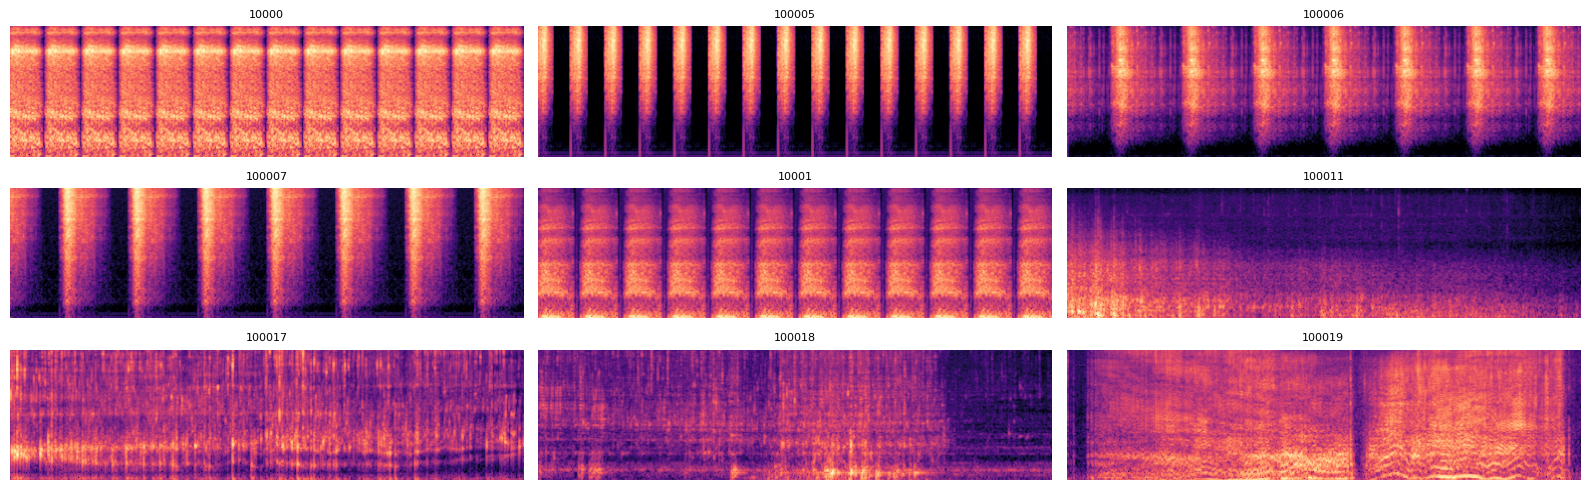

In [5]:
#preview a couple log mel spectrograms
N_PREVIEW = 9   # Number of files to process

specs = []
for p in wav_files[:N_PREVIEW]:
    s = audio_to_log_mel(p)
    specs.append(s)
    print(f"  {p.name:>12s}  →  {tuple(s.shape)}")


fig, axes = plt.subplots(3, 3, figsize=(16, 5))
axes = axes.flatten()

for i, (ax,p) in enumerate(zip(axes, wav_files[:N_PREVIEW])):
    ax.imshow(specs[i][0].numpy(), origin='lower', aspect='auto', cmap='magma')
    ax.set_title(p.stem, fontsize=8); ax.axis('off')

plt.tight_layout()
plt.show()

### Make dataframe

In [6]:
df                      = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'dev.csv')
df_train                = df[df['split'] == 'train'].reset_index(drop=True)
df_train['labels']   = df_train['labels'].apply(lambda x: x.split(','))
df_train['audio_path']  = df_train['fname'].apply(lambda x: os.path.join(audio, f'{x}.wav'))
print(df_train['audio_path'])

df_eval = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'eval.csv')
df_eval['labels']     = df_eval['labels'].apply(lambda x: x.split(','))
df_eval['audio_path'] = df_eval['fname'].apply(lambda x: os.path.join(FSD50K / 'FSD50K.eval_audio', f'{x}.wav'))

0         data\FSD50K.dev_audio\64760.wav
1         data\FSD50K.dev_audio\16399.wav
2         data\FSD50K.dev_audio\16401.wav
3         data\FSD50K.dev_audio\16402.wav
4         data\FSD50K.dev_audio\16404.wav
                       ...               
36791    data\FSD50K.dev_audio\102863.wav
36792    data\FSD50K.dev_audio\389607.wav
36793     data\FSD50K.dev_audio\90091.wav
36794    data\FSD50K.dev_audio\244718.wav
36795     data\FSD50K.dev_audio\24061.wav
Name: audio_path, Length: 36796, dtype: object


In [7]:
vocabulary = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'vocabulary.csv')
vocabulary.columns = ["index", "label", "mid"]
vocabulary             = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'vocabulary.csv')
vocabulary.columns     = ["index", "label", "mid"]
label_to_idx           = {label: idx for idx, label in enumerate(vocabulary['label'].unique())}
num_classes            = len(label_to_idx)

print(f"Train clips: {len(df_train)}")
print(f"Num classes: {num_classes}")

Train clips: 36796
Num classes: 199


### Normalise all spectrograms and save as .pt files


In [8]:
from tqdm import tqdm
"""
# Pass 1: Compute dataset-wide mean and std for normalisation
total_sum, total_sq_sum, total_count = 0.0, 0.0, 0
train_df = df[df['split'] == 'train']
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Computing normalisation stats"):
    path = audio / f"{row['fname']}.wav"
    spec = audio_to_log_mel(path, norm_mean=0.0, norm_std=1.0)
    total_sum    += spec.sum().item()
    total_sq_sum += (spec ** 2).sum().item()
    total_count  += spec.numel()

NORM_MEAN = total_sum / total_count
NORM_STD  = (total_sq_sum / total_count - NORM_MEAN ** 2) ** 0.5
print(f"NORM_MEAN = {NORM_MEAN:.2f}, NORM_STD = {NORM_STD:.2f}")

# Pass 2: Preprocess all files and save as .pt tensors
for split in ['train', 'val']:
    output_dir = Path(f"preprocessed/{split}")
    output_dir.mkdir(parents=True, exist_ok=True)
    split_df = df[df['split'] == split]
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Preprocessing {split}"):
        fname = row['fname']
        spec  = audio_to_log_mel(audio / f"{fname}.wav", NORM_MEAN, NORM_STD)
        torch.save(spec, output_dir / f"{fname}.pt")
"""


'\n# Pass 1: Compute dataset-wide mean and std for normalisation\ntotal_sum, total_sq_sum, total_count = 0.0, 0.0, 0\ntrain_df = df[df[\'split\'] == \'train\']\nfor _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Computing normalisation stats"):\n    path = audio / f"{row[\'fname\']}.wav"\n    spec = audio_to_log_mel(path, norm_mean=0.0, norm_std=1.0)\n    total_sum    += spec.sum().item()\n    total_sq_sum += (spec ** 2).sum().item()\n    total_count  += spec.numel()\n\nNORM_MEAN = total_sum / total_count\nNORM_STD  = (total_sq_sum / total_count - NORM_MEAN ** 2) ** 0.5\nprint(f"NORM_MEAN = {NORM_MEAN:.2f}, NORM_STD = {NORM_STD:.2f}")\n\n# Pass 2: Preprocess all files and save as .pt tensors\nfor split in [\'train\', \'val\']:\n    output_dir = Path(f"preprocessed/{split}")\n    output_dir.mkdir(parents=True, exist_ok=True)\n    split_df = df[df[\'split\'] == split]\n    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Preprocessing {split}"):\n      

### make function for torch dataloader:

In [9]:
# class dataset function
from torch.utils.data import Dataset, DataLoader
import torch

class FSD50KDataset(Dataset):
    def __init__(self, df, label_to_idx, num_classes, split='train'):
        self.df           = df.reset_index(drop=True)
        self.num_classes  = num_classes
        self.preprocessed = Path(f"preprocessed/{split}")
        self.split        = split

        # Precompute all label vectors once at init
        self.labels = torch.zeros(len(self.df), num_classes)
        for i, row in self.df.iterrows():
            for lbl in row['labels']:
                lbl = lbl.strip()
                if lbl in label_to_idx:
                    self.labels[i, label_to_idx[lbl]] = 1.0
        self.fnames = self.df['fname'].tolist()  # in __init__
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        spec = torch.load(self.preprocessed / f"{self.fnames[idx]}.pt")
        #if self.split == 'train':
        #    spec = augment_spec(spec)  # calls the free function
        return spec, self.labels[idx]

In [10]:
train_dataset = FSD50KDataset(df_train, label_to_idx, num_classes)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# verify it works
specs, labels = next(iter(train_loader))
print("Spec shape:", specs.shape)    # should be (32, 1, 128, 512)
print("Label shape:", labels.shape)  # should be (32, 199)
print(f"num_classes from vocabulary: {num_classes}")
print(f"num_classes from label shape: {labels.shape[1]}")
print(f"classes in label_to_idx:     {len(label_to_idx)}")

Spec shape: torch.Size([32, 1, 128, 512])
Label shape: torch.Size([32, 199])
num_classes from vocabulary: 199
num_classes from label shape: 199
classes in label_to_idx:     199


In [11]:
#classifier
import torch.nn as nn
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [12]:
#fraction and data laoder
# ── Small fraction for quick test ─────────────────────────────────────────────
fraction    = 1
df_small    = df_train.sample(frac=fraction, random_state=42).reset_index(drop=True)
df_val      = df[df['split'] == 'val'].reset_index(drop=True)
df_val['labels']     = df_val['labels'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
df_val['audio_path'] = df_val['fname'].apply(lambda x: os.path.join(audio, f'{x}.wav'))
df_val_small = df_val.sample(frac=fraction, random_state=42).reset_index(drop=True)

train_dataset = FSD50KDataset(df_small,     label_to_idx, num_classes, split='train')
val_dataset   = FSD50KDataset(df_val_small, label_to_idx, num_classes, split='val')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

In [ ]:
from tqdm import tqdm

# ── Training setup ─────────────────────────────────────────────────────────────
epochs    = 30
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = AudioCNN(num_classes=num_classes).to(device)
#criterion = nn.BCEWithLogitsLoss()

# Compute pos_weight from training labels
all_labels = all_labels = train_dataset.labels
pos        = all_labels.sum(dim=0).clamp(min=1)
neg        = len(all_labels) - pos
pos_weight = (neg / pos).to(device)   # shape: (num_classes,)
pos_weight = (neg / pos).clamp(max=10.0).to(device)

# Step 2: Focal loss with pos_weight
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce  = nn.functional.binary_cross_entropy_with_logits(
                   logits, targets, pos_weight=self.pos_weight, reduction='none')
        prob = torch.sigmoid(logits)
        p_t  = targets * prob + (1 - targets) * (1 - prob)
        return (bce * (1 - p_t) ** self.gamma).mean()

criterion = FocalLoss(gamma=2.0, pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# After creating your model, before training:
prior      = all_labels.mean(dim=0).clamp(1e-4, 1 - 1e-4)
init_bias  = torch.log(prior / (1 - prior))   # inverse sigmoid of prior
model.classifier[-1].bias.data.copy_(init_bias.to(device))

print(f"pos_weight min:  {pos_weight.min().item():.1f}")
print(f"pos_weight max:  {pos_weight.max().item():.1f}")
print(f"pos_weight mean: {pos_weight.mean().item():.1f}")

pos_weight min:  2.2
pos_weight max:  10.0
pos_weight mean: 9.9


In [ ]:
# ── Training loop ──────────────────────────────────────────────────────────────
def train_one_epoch(loader, epoch_bar):
    model.train()
    total_loss = 0
    with tqdm(loader, desc="  Train", leave=False, unit="batch") as batch_bar:
        for specs, labels in batch_bar:
            specs, labels = specs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(specs), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    scheduler.step()
    return total_loss / len(loader)

def evaluate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        with tqdm(loader, desc="    Val", leave=False, unit="batch") as batch_bar:
            for specs, labels in batch_bar:
                specs, labels = specs.to(device), labels.to(device)
                loss = criterion(model(specs), labels)
                total_loss += loss.item()
                batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)
"""
# ── Epoch loop ─────────────────────────────────────────────────────────────────
with tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:
    for epoch in epoch_bar:
        train_loss = train_one_epoch(train_loader, epoch_bar)
        val_loss   = evaluate(val_loader)
        lr         = scheduler.get_last_lr()[0]
        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")
        tqdm.write(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {lr:.2e}")
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
"""

'\nhistory = {\'train_loss\': [], \'val_loss\': [], \'map\': []}\n\n# ── Epoch loop ─────────────────────────────────────────────────────────────────\nwith tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:\n    for epoch in epoch_bar:\n        train_loss = train_one_epoch(train_loader, epoch_bar)\n        val_loss   = evaluate(val_loader)\n        lr         = scheduler.get_last_lr()[0]\n        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")\n        tqdm.write(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {lr:.2e}")\n        history[\'train_loss\'].append(train_loss)\n        history[\'val_loss\'].append(val_loss)\n\ntorch.save(model.state_dict(), \'best_weighted_model.pt\')\n'

In [15]:
#evaluate metrics function
from sklearn.metrics import accuracy_score, hamming_loss, f1_score, average_precision_score
def evaluate_metrics(loader, threshold=0.3):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for specs, labels in loader:
            probs = torch.sigmoid(model(specs.to(device))).cpu()
            preds = (probs > threshold).float()
            all_preds.append(preds)
            all_labels.append(labels)
            all_probs.append(probs)

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs  = torch.cat(all_probs).numpy()

    print(f"Threshold: {threshold}")
    print(f"Exact Match Accuracy: {accuracy_score(all_labels, all_preds):.4f}  (strictest)")
    print(f"Hamming Accuracy:     {1 - hamming_loss(all_labels, all_preds):.4f}  (most lenient)")
    print(f"F1 Macro:             {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
    print(f"F1 Micro:             {f1_score(all_labels, all_preds, average='micro', zero_division=0):.4f}")

    return all_preds, all_labels, all_probs


In [ ]:

# initialise history before the loop
history = {'train_loss': [], 'val_loss': [], 'map': []}

best_val_loss = float('inf')
no_improve    = 0
patience      = 5

with tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:
    for epoch in epoch_bar:
        train_loss = train_one_epoch(train_loader, epoch_bar)
        val_loss   = evaluate(val_loader)
        lr         = scheduler.get_last_lr()[0]
        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")
        tqdm.write(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr:.2e}")
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve    = 0
            torch.save(model.state_dict(), 'best_weighted_model.pt')
            tqdm.write(f"  → New best val loss {val_loss:.4f} saved at epoch {epoch+1}")
        else:
            no_improve += 1

        if no_improve >= patience:
            tqdm.write(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 1 == 0:
            _, labels_np, probs_np = evaluate_metrics(val_loader)
            current_map = average_precision_score(labels_np, probs_np, average='macro')
            history['map'].append((epoch + 1, current_map))
            tqdm.write(f"  mAP at epoch {epoch+1}: {current_map:.4f}")

model.load_state_dict(torch.load('best_weighted_model.pt'))


Epochs:   5%|▌         | 1/20 [48:27<15:20:40, 2907.40s/epoch, lr=9.94e-04, train=0.0842, val=0.0887]

Epoch 01 | Train: 0.0842 | Val: 0.0887 | LR: 9.94e-04
  → New best val loss 0.0887 saved at epoch 1


Epochs:  10%|█         | 2/20 [1:34:00<14:01:30, 2805.04s/epoch, lr=9.76e-04, train=0.0613, val=0.0773]

Epoch 02 | Train: 0.0613 | Val: 0.0773 | LR: 9.76e-04
  → New best val loss 0.0773 saved at epoch 2


Epochs:  10%|█         | 2/20 [2:16:44<14:01:30, 2805.04s/epoch, lr=9.46e-04, train=0.0537, val=0.0682]

...

Epochs:  95%|█████████▌| 19/20 [12:39:26<36:20, 2180.02s/epoch, lr=6.16e-06, train=0.0255, val=0.0534]  

Epoch 19 | Train: 0.0255 | Val: 0.0534 | LR: 6.16e-06


Epochs: 100%|██████████| 20/20 [13:14:23<00:00, 2383.19s/epoch, lr=0.00e+00, train=0.0252, val=0.0530]

Epoch 20 | Train: 0.0252 | Val: 0.0530 | LR: 0.00e+00


<All keys matched successfully>

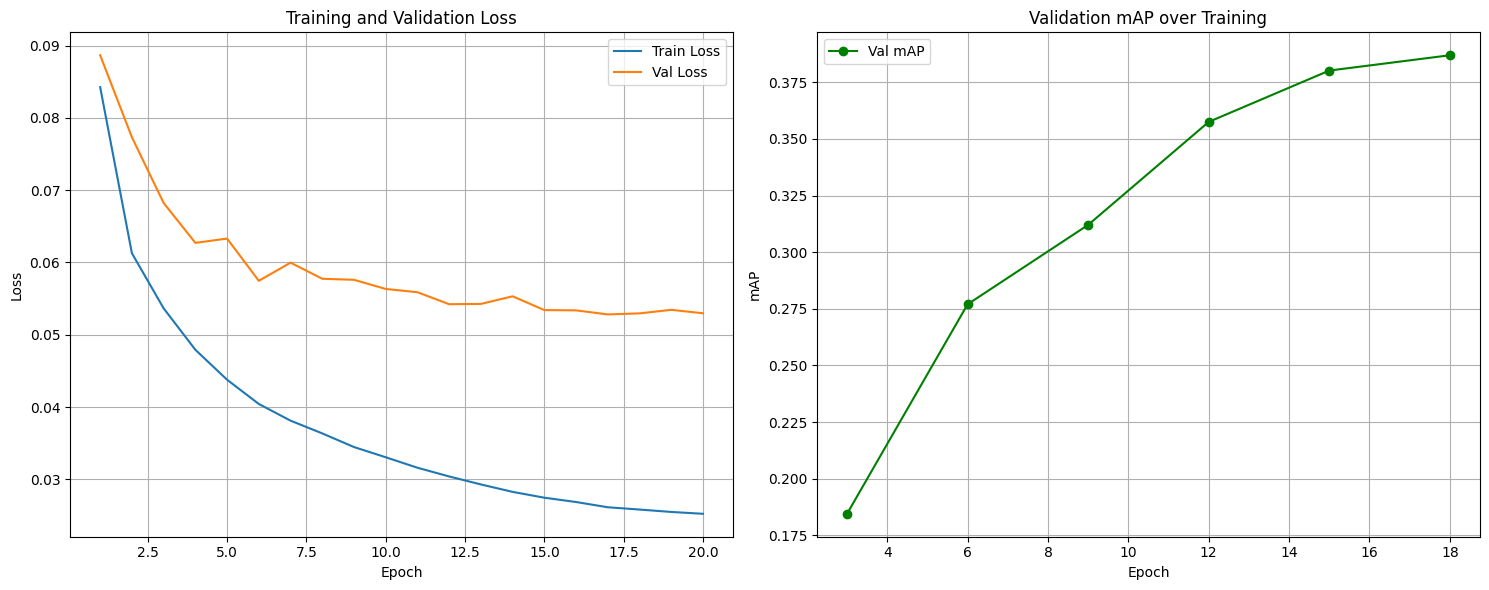

In [21]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 1: Loss curves
ax1.plot(epochs_ran, history['train_loss'], label='Train Loss')
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Figure 2: mAP curve — unpack tuples
if history['map']:
    map_epochs, map_values = zip(*history['map'])
    ax2.plot(map_epochs, map_values, label='Val mAP', color='green', marker='o')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('mAP')
    ax2.set_title('Validation mAP over Training')
    ax2.legend()
    ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [19]:
#first evals
model.eval()
with torch.no_grad():
    specs, labels = next(iter(val_loader))
    probs = torch.sigmoid(model(specs.to(device))).cpu()
    print("Mean predicted probability:", probs.mean().item())   # will be near 0
    print("Max predicted probability: ", probs.max().item())    # will be low
    print("Labels positive rate:      ", labels.mean().item())  # ~0.01–0.02

Mean predicted probability: 0.1006699874997139
Max predicted probability:  0.9100751876831055
Labels positive rate:       0.01460427138954401


In [29]:
all_preds, all_labels, all_probs = evaluate_metrics(val_loader, threshold=0.3)

Threshold: 0.3
Exact Match Accuracy: 0.0098  (strictest)
Hamming Accuracy:     0.9208  (most lenient)
F1 Macro:             0.2257
F1 Micro:             0.2577


In [22]:
#finding least represented classes in the training set
from collections import Counter
df_f1 = pd.DataFrame({
    'class': vocabulary['label'],
    'f1_score': f1_score(all_labels, all_preds, average=None, zero_division=0)
}).sort_values('f1_score')

label_counts = Counter()
for labels in df_train['labels']:
    for l in labels:
        label_counts[l.strip()] += 1

# Check your worst performers
worst = df_f1.tail(10)['class'].tolist()
for cls in worst:
    print(f"{cls:30s}: {label_counts.get(cls, 0)} samples")

Crash_cymbal                  : 178 samples
Bark                          : 352 samples
Snare_drum                    : 648 samples
Applause                      : 328 samples
Cowbell                       : 148 samples
Hi-hat                        : 384 samples
Trumpet                       : 504 samples
Cymbal                        : 560 samples
Music                         : 11610 samples
Musical_instrument            : 11609 samples


In [ ]:
#f1 score threshold tuning
from sklearn.metrics import f1_score

# Find optimal threshold per class
best_thresholds = []
for i in range(all_labels.shape[1]):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs[:, i] > t).astype(float)
        f1 = f1_score(all_labels[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds.append(best_t)

best_thresholds = np.array(best_thresholds)
print("Best thresholds per class:", best_thresholds)

all_preds_tuned = (all_probs > best_thresholds).astype(float)
#print(f"F1 Micro (tuned): {f1_score(all_labels, all_preds_tuned, average='micro', zero_division=0):.4f}")
#print(f"F1 Macro (tuned): {f1_score(all_labels, all_preds_tuned, average='macro', zero_division=0):.4f}")
# f1 micro tells the accu½racy of the model, while f1 macro tells the average f1 score across all classes,
#  giving equal weight to each class regardless of frequency.


# mAP
map_score = average_precision_score(all_labels, all_probs, average='macro')
#print(f"mAP: {map_score:.4f}")

families = ['Music', 'Human_voice', 'Domestic_sounds_and_home_sounds', 
            'Animal', 'Vehicle', 'Natural_sounds']

family_idx = [label_to_idx[f] for f in families if f in label_to_idx]
map_families = average_precision_score(
    all_labels[:, family_idx], 
    all_probs[:, family_idx], 
    average='macro'
)
#print(f"mAP (6 families only): {map_families:.4f}")

Best thresholds per class: [0.65 0.5  0.5  0.6  0.65 0.45 0.4  0.6  0.55 0.55 0.6  0.55 0.5  0.65
 0.55 0.35 0.45 0.5  0.6  0.55 0.65 0.5  0.35 0.3  0.6  0.5  0.5  0.55
 0.4  0.55 0.55 0.5  0.5  0.6  0.5  0.45 0.5  0.5  0.55 0.55 0.5  0.55
 0.45 0.65 0.5  0.55 0.5  0.55 0.5  0.45 0.45 0.6  0.45 0.5  0.4  0.5
 0.55 0.5  0.6  0.6  0.55 0.5  0.45 0.4  0.5  0.5  0.55 0.65 0.7  0.6
 0.45 0.6  0.55 0.45 0.45 0.4  0.45 0.55 0.55 0.45 0.5  0.4  0.45 0.4
 0.45 0.6  0.45 0.45 0.4  0.65 0.45 0.6  0.4  0.4  0.55 0.5  0.4  0.5
 0.5  0.55 0.65 0.4  0.55 0.6  0.6  0.5  0.65 0.6  0.5  0.45 0.6  0.65
 0.65 0.4  0.55 0.5  0.45 0.6  0.45 0.45 0.45 0.55 0.55 0.4  0.6  0.6
 0.6  0.5  0.5  0.35 0.5  0.45 0.6  0.65 0.5  0.4  0.5  0.6  0.65 0.35
 0.5  0.45 0.5  0.6  0.6  0.25 0.55 0.45 0.5  0.55 0.45 0.45 0.5  0.5
 0.55 0.4  0.55 0.65 0.5  0.5  0.45 0.55 0.25 0.55 0.5  0.7  0.4  0.55
 0.65 0.55 0.55 0.55 0.45 0.45 0.5  0.55 0.45 0.55 0.55 0.5  0.25 0.45
 0.65 0.6  0.55 0.45 0.6  0.55 0.5  0.55 0.55 0.7  0.5  

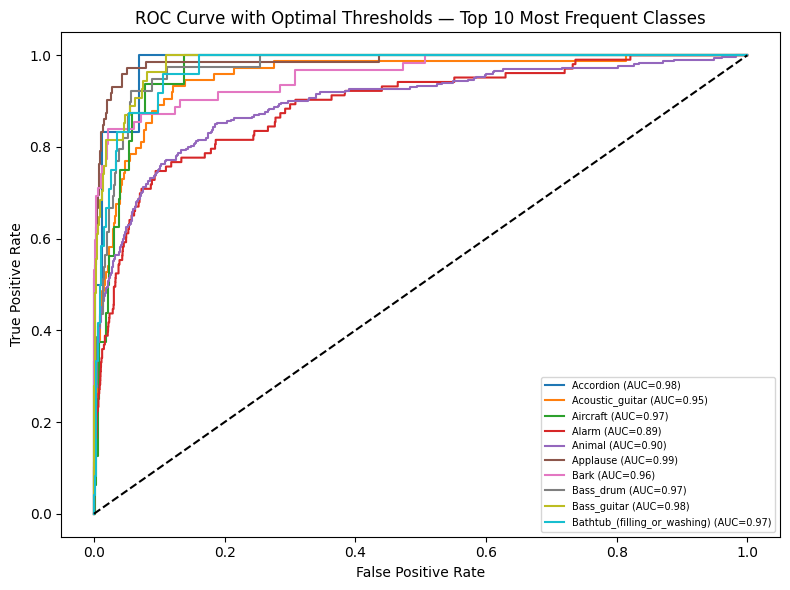

In [25]:
#ROC-curve with optimal thresholds for 10 best classes
from sklearn.metrics import roc_curve, auc
top10_idx = np.argsort(df_f1['f1_score'].values)[:10]
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

                                                 
fig, ax = plt.subplots(figsize=(8, 6))
for i in top10_idx:
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, label=f"{idx_to_label[i]} (AUC={auc(fpr,tpr):.2f})")
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve with Optimal Thresholds — Top 10 Most Frequent Classes")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [26]:
#dprime and lwlrap functions
from scipy.stats import norm
from sklearn.metrics import roc_auc_score
import numpy as np

def dprime(all_labels, all_probs):
    valid = (all_labels.sum(axis=0) > 0) & (all_labels.sum(axis=0) < len(all_labels))
    auc = roc_auc_score(all_labels[:, valid], all_probs[:, valid], average='macro')
    return np.sqrt(2) * norm.ppf(auc)

dp = dprime(all_labels, all_probs)

def lwlrap(all_labels, all_probs):
    """Label-weighted label-ranking average precision."""
    num_samples, num_classes = all_labels.shape
    
    # Only consider samples that have at least one positive label
    has_pos = all_labels.sum(axis=1) > 0
    labels  = all_labels[has_pos]
    probs   = all_probs[has_pos]
    
    per_sample_ap = []
    per_sample_weight = []
    
    for i in range(len(labels)):
        pos_classes = np.where(labels[i] > 0)[0]
        if len(pos_classes) == 0:
            continue
        
        # Rank classes by predicted probability (descending)
        ranked = np.argsort(-probs[i])
        
        # Compute precision at each positive label in the ranking
        precisions = []
        num_correct = 0
        for rank, cls in enumerate(ranked):
            if cls in pos_classes:
                num_correct += 1
                precisions.append(num_correct / (rank + 1))
            if num_correct == len(pos_classes):
                break
        
        per_sample_ap.append(np.mean(precisions))
        per_sample_weight.append(len(pos_classes))
    
    weights = np.array(per_sample_weight)
    aps     = np.array(per_sample_ap)
    return np.sum(weights * aps) / np.sum(weights)

lwlrap_score = lwlrap(all_labels, all_probs)

In [30]:
#metrics for evaluating

print(f"F1 Micro (tuned): {f1_score(all_labels, all_preds_tuned, average='micro', zero_division=0):.4f}")
print(f"F1 Macro (tuned): {f1_score(all_labels, all_preds_tuned, average='macro', zero_division=0):.4f}")

map_score    = average_precision_score(all_labels, all_probs, average='macro')
dp           = dprime(all_labels, all_probs)
lwlrap_score = lwlrap(all_labels, all_probs)

print(f"mAP:    {map_score:.3f}  (paper CRNN: 0.417, VGG-like: 0.434)")
print(f"d':     {dp:.3f}         (paper CRNN: 2.068, VGG-like: 2.167)")
print(f"lωlrap: {lwlrap_score:.3f}  (paper CRNN: 0.519, VGG-like: 0.514)")
print(f"mAP (6 families only): {map_families:.4f}")

F1 Micro (tuned): 0.5454
F1 Macro (tuned): 0.4276
mAP:    0.385  (paper CRNN: 0.417, VGG-like: 0.434)
d':     2.286         (paper CRNN: 2.068, VGG-like: 2.167)
lωlrap: 0.649  (paper CRNN: 0.519, VGG-like: 0.514)
mAP (6 families only): 0.6774
